## Setup
imports, data download, train/test split — everything needed for the better classifier section

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

In [4]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

In [5]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

In [6]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Building a better classifier

In [7]:
knn_clf = KNeighborsClassifier()
knn_preds = cross_val_predict(knn_clf, X_train, y_train, cv=3, n_jobs=-1)

In [ ]:
print(classification_report(y_train, knn_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      5923
           1       0.95      0.99      0.97      6742
           2       0.98      0.96      0.97      5958
           3       0.96      0.96      0.96      6131
           4       0.98      0.96      0.97      5842
           5       0.96      0.96      0.96      5421
           6       0.98      0.99      0.98      5918
           7       0.96      0.97      0.97      6265
           8       0.98      0.92      0.95      5851
           9       0.95      0.96      0.95      5949

    accuracy                           0.97     60000
   macro avg       0.97      0.97      0.97     60000
weighted avg       0.97      0.97      0.97     60000



In [ ]:
print(accuracy_score(y_train, knn_preds))

0.9674166666666667


default works pretty well tbh, let's just tune the hyperparameters a bit

get our grid of parameters, and do a grid search for the best params.

we can fit on a subset of the data, and then refit on the entire set of data with the best set of params

this means we get the biggest improvement, and then make tiny microadjustments based on the entire set

In [ ]:
knn_clf = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 4, 5, 6, 7],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(knn_clf, param_grid, cv=3, n_jobs=-1, verbose=2) # n_jobs=-1 runs fits on all available cpu cores at once

grid_search.fit(X_train[:10000], y_train[:10000]) # fit on a subset of the data to make it faster
grid_search.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END ....................n_neighbors=3, weights=distance; total time=   2.2s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   2.6s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   2.4s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   2.5s
[CV] END ....................n_neighbors=3, weights=distance; total time=   2.5s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   2.6s
[CV] END ....................n_neighbors=3, weights=distance; total time=   2.5s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   2.7s
[CV] END ....................n_neighbors=4, weights=distance; total time=   2.8s
[CV] END ....................n_neighbors=4, weights=distance; total time=   2.8s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   2.9s
[CV] END .....................n_neighbors=5, wei

{'n_neighbors': 4, 'weights': 'distance'}

In [ ]:
print(grid_search.best_score_) # cv score of the best combination
model = grid_search.best_estimator_
# print(grid_search.cv_results_)

0.9397994088551026


In [ ]:
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
test_preds = model.predict(X_test)
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      1.00      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.97      0.96      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.97      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.97      0.96      1028
           8       0.99      0.94      0.97       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
print(accuracy_score(y_test, test_preds))

0.9763


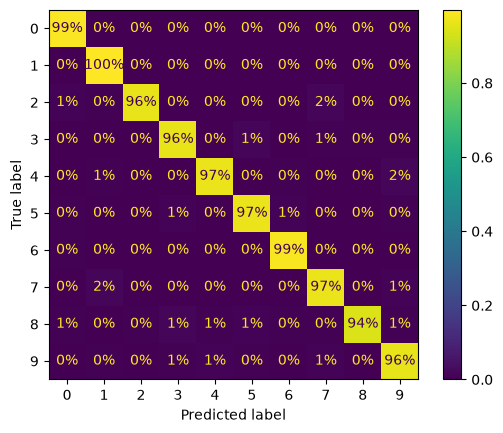

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, normalize='true', values_format='.0%')

wow this is pretty insanely good, doesnt really have a blatant error or anything. 

## Shifting the image

let's write a function that shifts an image  

In [ ]:
from scipy.ndimage import shift

# need to write a function that shifts an image

# this function takes in an image and how much to shift it by, reshapes and shifts the image 
#   and puts it back how it originally was (-1 flattens it into a 1d array)
def shift_image(image, x, y):
    return shift(image.reshape(28,28), [x,y], cval=0).reshape(-1) # cval = 0 means to fill the empty part of the image with 0 

now that we have our function, we need to go through the training set, and create a new shifted each image up/down/left/right. we can then add all these to the training set.

In [ ]:
# add everything to a normal python list first, it's faster since np.append() copies over the entire thing
shifted_images = []
shifted_images_labels = []

for i in range(np.shape(X_train)[0]):
    image = X_train[i]
    shifted_images.append(shift_image(image, 1, 0))
    shifted_images.append(shift_image(image, -1, 0))
    shifted_images.append(shift_image(image, 0, 1))
    shifted_images.append(shift_image(image, 0,-1))
    for j in range(4):
        shifted_images_labels.append(y_train[i])

In [ ]:
shifted_images = np.array(shifted_images)
shifted_images_labels = np.array(shifted_images_labels)

In [ ]:
print(shifted_images.shape)
print(X_train.shape)

(240000, 784)
(60000, 784)


In [ ]:
X_train_with_shifted = np.append(X_train, shifted_images, axis=0) # axis=0 means that rows (the actual images) will be added below the orignal rows
y_train_with_shifted = np.append(y_train, shifted_images_labels, axis=0)

In [ ]:
print(X_train_with_shifted.shape)
print(y_train_with_shifted.shape)

(300000, 784)
(300000,)


In [ ]:
model.fit(X_train_with_shifted, y_train_with_shifted)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
test_preds = model.predict(X_test)
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.97      1.00      0.98      1135
           2       0.99      0.97      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.97      0.97       892
           6       0.98      0.99      0.99       958
           7       0.97      0.97      0.97      1028
           8       0.99      0.95      0.97       974
           9       0.96      0.97      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
print(accuracy_score(y_test, test_preds))

0.9763


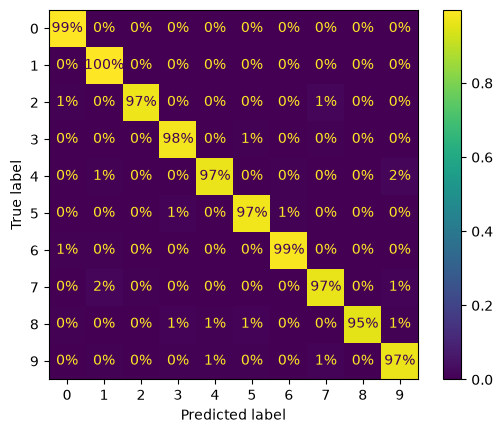

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, normalize='true', values_format='.0%')

not bad, that's an improvement


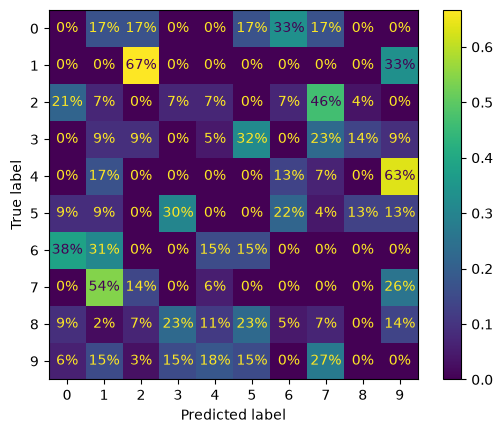

In [ ]:
sample_weight = (test_preds != y_test)
ConfusionMatrixDisplay.from_predictions(y_test , test_preds,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

a handful of larger error categories, but nothing insanely huge